## I. Google Play Store "apps" and "reviews"
<p>Las aplicaciones móviles están en todas partes. Son fáciles de crear y pueden resultar muy lucrativas. Debido a estos dos factores, se están desarrollando cada vez más aplicaciones. En este ejercicio, haremos un análisis completo del mercado de aplicaciones de Android comparando más de diez mil aplicaciones en Google Play en diferentes categorías. Buscaremos información valiosa en los datos para diseñar estrategias que impulsen el crecimiento, la retención y monetizacion.</p>
<p><img src="https://assets.datacamp.com/production/project_619/img/google_play_store.png" alt="Google Play logo"></p>
<p>Tenemos dos fuentes de datos:</p>
<ul>
<li><code>apps.csv</code>: contiene todos los detalles de las aplicaciones en Google Play. Hay 13 características que describen una aplicación determinada.</li>
<li><code>user_reviews.csv</code>: contiene 100 reseñas para cada aplicación, <a href="https://www.androidpolice.com/2019/01/21/google-play-stores-redesigned-ratings-and-reviews-section-lets-you-easily-filter-by-star-rating/">reviews</a>. El texto de cada reseña se ha procesado previamente y se le atribuyen tres características nuevas: Sentimiento (positivo, negativo o neutral), Polaridad del sentimiento y Subjetividad del sentimiento..</li>
</ul>

In [2]:
# Importamos las librerías para cargar nuestra fuente de datos "apps.csv"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("C:/Users/hiram/Downloads")
# Importamos el datase apps.csv
apps=pd.read_csv("apps.csv")
# Borramos todos los duplicados del dataset
apps=apps.drop_duplicates()
# Imprimimos el total de apps que se van a analizar que quedan (dimensión)
print('Total number of apps in the dataset = ',apps.shape[0])
# Imprimimos la estádistica descriptiva de resumen
print(apps.describe())
# Echamos un vistazo al DataFrame final
print(apps.head())

Total number of apps in the dataset =  9659
            Rating       Reviews         Size
count  8196.000000  9.659000e+03  8432.000000
mean      4.173243  2.165926e+05    20.395327
std       0.536625  1.831320e+06    21.827509
min       1.000000  0.000000e+00     0.000000
25%       4.000000  2.500000e+01     4.600000
50%       4.300000  9.670000e+02    12.000000
75%       4.500000  2.940100e+04    28.000000
max       5.000000  7.815831e+07   100.000000
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

   Reviews  Size     Installs  Type Price Content Rating  \
0

## II. Data cleaning
<p>Las cuatro variables con las que trabajaremos con más frecuencia de ahora en adelante son <i>Installs</i>, <i>Size</i>, <i>Rating</i> y <i>Price</i>. La función <code>info()</code> nos dice que las columnas <i>Installs</i> y <i>Price</i> son de tipo <code>object</code>, no son de tipo <code>int</code> o <code>float</code> como esperaríamos. Esto se debe a que la columna contiene algunos caracteres más que solo [0,9] dígitos. Idealmente, queremos que estas columnas fueran puramente numéricas<br>
<br>
Por lo tanto, ahora necesitamos limpiar nuestros datos. Específicamente, los caracteres especiales <code>,</code> y <code>+</code> que se encuentran en la columna <i>Installs</i> y <code>$</code> que esta en la columna <i>Price</i>.</p>

<p>Aquí un link donde podrás ver un poco más a detalle que es una <a href="https://www.freecodecamp.org/espanol/news/expresiones-lambda-en-python/">función lambda</a>

In [4]:
# Lista de caracteres a eliminar
chars_to_remove = [",","+","$"]
# Lista de las columnas a limpiar
cols_to_clean = ["Installs","Price"]
# Loop para cada columna
for col in cols_to_clean:
    # Loop para cada caracter especial
    for char in chars_to_remove:
        # Reemplaza con una función lambda el caracter especial por un texto vacío ('')
        apps[col] = apps[col].apply(lambda x: x.replace(char,""))
    # Convierte la columna a tipo flotante (float)
    apps[col] = apps[col].astype(float)
# Lista de fechas convertida a INT
apps['Last Updated'] = pd.to_datetime(apps['Last Updated']).dt.strftime('%Y%m%d').astype(int)


## III. Exploring App's categories
<p>Con más de mil millones de usuarios activos en 190 países de todo el mundo, Google Play sigue siendo una importante plataforma de distribución para crear una audiencia global. Para que las empresas muestren sus aplicaciones a los usuarios, es importante hacerlas más rápida y fácilmente visibles en Google Play. Para mejorar la experiencia de búsqueda general, Google ha introducido el concepto de agrupar aplicaciones en categorías.</p>
<p>Esto nos lleva a las siguientes preguntas:</p>
<ul>
<li>¿Qué categoría tiene la mayor participación de aplicaciones (activas) en el mercado?</li>
<li>¿Alguna categoría específica domina el mercado?</li>
<li>¿Qué categorías tienen la menor cantidad de aplicaciones?</li>
</ul>
<p>Vamos a responder estas preguntas aquí <code>33</code> categorías unicas estan presentas en nuestro dataset. Las apps de <em>Family</em> y <em>Game</em> tienen la mayor prevalencia del mercado. Curiosamente, <em>Tools</em>, <em>Business</em> y <em>Medical</em> también están en el top.</p>

Number of categories =  33


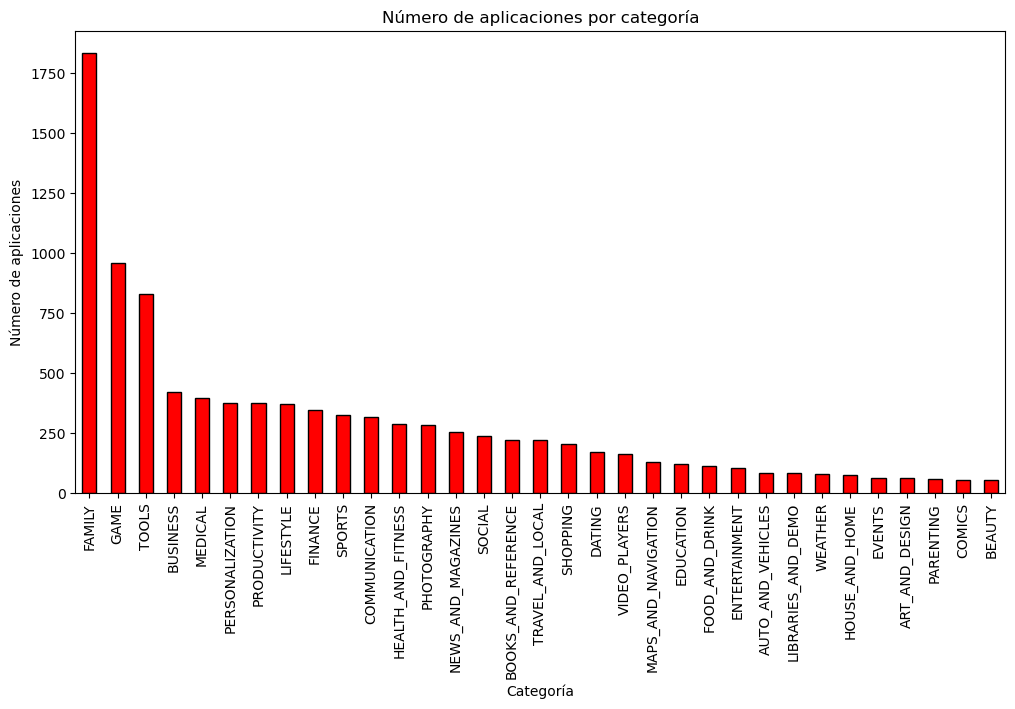

In [6]:
# Imprimimos el total de categorías únicas
num_categories =apps["Category"].nunique()
print('Number of categories = ', num_categories)
# Contamos el número de aplicaciones en cada Categoría y ordena de manera descendente 
num_apps_in_category = apps["Category"].value_counts()
# Muestramos el resultado en una gráfica de barras
num_apps_in_category.plot(kind="bar", figsize=(12, 6), color="red",edgecolor="black")
plt.style.use("grayscale")
plt.xlabel("Categoría")
plt.ylabel("Número de aplicaciones")
plt.title("Número de aplicaciones por categoría")
plt.xticks(rotation=90)
plt.show()

## IV. Ratings Distribution
<p>Después de analizar la participación de mercado para cada categoría de las aplicaciones, veamos cómo se posicionan de acuerdo a las calificaciones (en una escala del 1 al 5) las cuales afectan la imagen de la marca general de la empresa. Las calificaciones son un indicador clave de rendimiento de una aplicación.</p>

Average app rating =  4.173243045387994
Category
EVENTS                 4.435556
EDUCATION              4.364407
ART_AND_DESIGN         4.357377
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
GAME                   4.247368
SOCIAL                 4.247291
WEATHER                4.243056
HEALTH_AND_FITNESS     4.243033
SHOPPING               4.230000
SPORTS                 4.216154
AUTO_AND_VEHICLES      4.190411
PRODUCTIVITY           4.183389
COMICS                 4.181481
FAMILY                 4.179664
LIBRARIES_AND_DEMO     4.178125
FOOD_AND_DRINK         4.172340
MEDICAL                4.166552
PHOTOGRAPHY            4.157414
HOUSE_AND_HOME         4.150000
ENTERTAINMENT          4.135294
NEWS_AND_MAGAZINES     4.121569
COMMUNICATION          4.121484
FINANCE                4.115563
BUSINESS               4.098479
LIFESTYLE              4.093355
TRAVEL_AND_LOCAL       4.069519
VIDEO_PLAYERS          

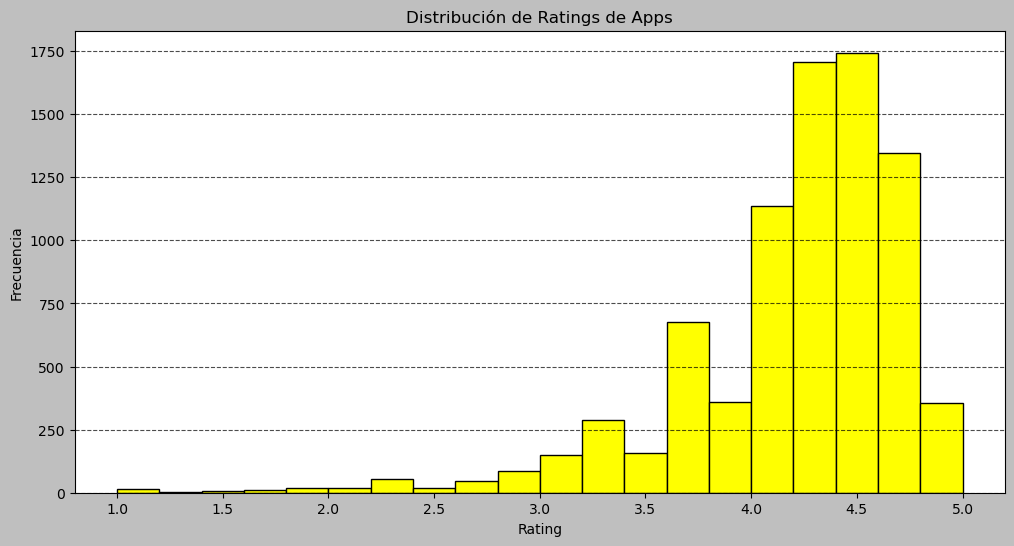

In [8]:
# Calculamos el promedio de calificación de las apps
avg_app_rating = apps["Rating"].mean()
print('Average app rating = ', avg_app_rating)

# Calculamos el promedio de calificación por categoría
avg_rating_per_category = apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)
print(avg_rating_per_category)

# Visualizamos en un histograma el comportamiento del Rating
plt.figure(figsize=(12, 6))
plt.hist(apps["Rating"].dropna(), bins=20, color="yellow", edgecolor="black")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.title("Distribución de Ratings de Apps")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## V. Size and Price
<p>Examinemos ahora el tamaño y el precio de la aplicación. En cuanto al tamaño, si la aplicación móvil es demasiado grande, puede ser difícil y/o costoso para los usuarios descargarla. Los tiempos de descarga prolongados pueden desanimar a los usuarios incluso antes de que experimenten su aplicación móvil. Además, el dispositivo de cada usuario tiene una cantidad limitada de espacio en disco. Por el precio, algunos usuarios esperan que sus aplicaciones sean gratuitas o económicas. Estos problemas se agravan si el mercado objetivo es en países en vías de desarrollo; especialmente debido a las velocidades de Internet, el poder adquisitivo, los tipos de cambio, etc.</p>
<p>How can we effectively come up with strategies to size and price our app?</p>
<ul>
<li>¿El tamaño de una aplicación afecta su calificación?</li>
<li>¿Los usuarios realmente se preocupan por las aplicaciones pesadas del sistema o prefieren las aplicaciones ligeras? </li>
<li>¿El precio de una aplicación afecta su calificación? </li>
<li>¿Los usuarios siempre prefieren las aplicaciones gratuitas a las de paga?</li>
</ul>

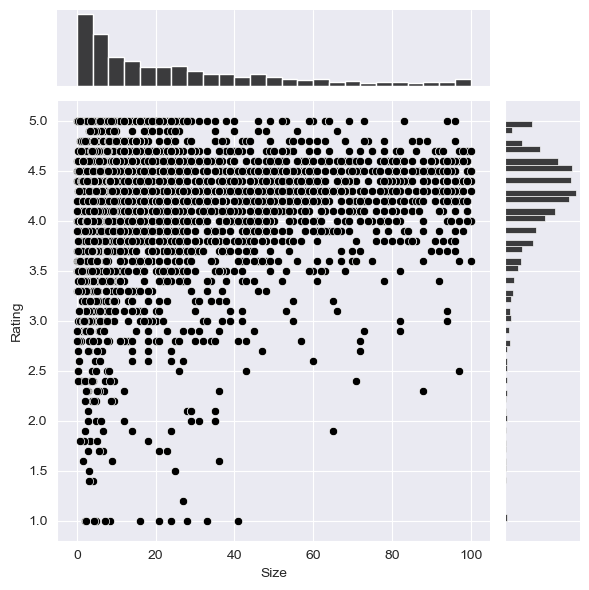

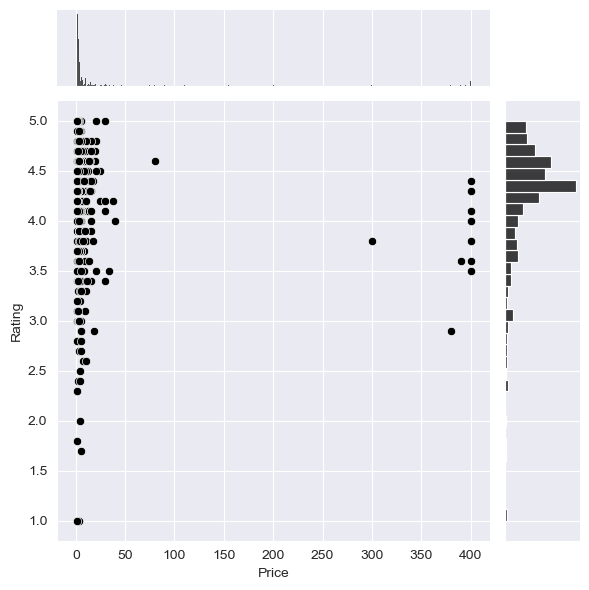

In [10]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_style("darkgrid")

# Filtramos las filas donde los valores de 'Rating' y 'Size' no sean nulos
apps_with_size_and_rating_present = apps.dropna(subset=["Rating", "Size"])

# Filtramos las categorías con al menos 250 apps
large_categories = apps_with_size_and_rating_present.groupby("Category").filter(lambda x: len(x) >= 250)

# Gráfica size vs. rating
plt1 = sns.jointplot(x = large_categories["Size"], y = large_categories["Rating"])
# Selecciona las apps de paga 'Type' = 'Paid'
paid_apps = apps[apps["Type"] == "Paid"]
# Grafica price vs. rating de las paplicaciones de paga
plt2 = sns.jointplot(x = paid_apps["Price"], y = paid_apps["Rating"])
plt.show()

<P> Se puede observar que el peso de una app es un valor crucial a la hora de que un usuario pueda descargarla tomando asi la decision de dedicarle un espacio a la fidelidad para esa app pero asi tambien es facil no destacar entre la cantidad donde apps que dedican mas tiempo al rendimiento, a costa de un peso mayor y de la posible perdida de publico que no cuenta con el espacio no obte por ella se centran en un publico mas actualizado(desarrollado) y esta dedicancion de espacio extra se ve reflejada en poder optener una mayor aceptacion por el publico; por otro lado si nuestro enfoque es un publico que pueda adquirir con un pago nuestra el resulotado es muy mixto y parecido a la importancia del peso donde el rating recaera si el usuario piensa que su dinero lo ah valido, pero si exageramos este precio aseguramos un pequeño descontento donde las exigencias seran mas al ser un golpe mas duro qal bolsillo asegurando una caida en la aceptacion

## VI. Relation between Category & Price
<p>Así que ahora viene la parte difícil. ¿Cómo se supone que las empresas y los desarrolladores cubran sus cuotas de fin de mes? ¿Qué estrategias de monetización pueden utilizar las empresas para maximizar las ganancias? Los costos de las aplicaciones se basan en gran medida en las características, la complejidad y la plataforma. Hay muchos factores a considerar al seleccionar la estrategia de precios adecuada para las aplicaciones moviles. Es importante considerar la disposición de su cliente a pagar por la aplicación. Un precio elevado puede hacer que los clientes no se vean atraídos por descargarlaque ocurra la descarga o pueden eliminar una aplicación que han descargado después de recibir demasiados anuncios o simplemente no obtener el valor que esperaban de su dinero.</p>

<p>Las diferentes categorías exigen diferentes rangos de precios. Algunas aplicaciones que son simples y se usan a diario, como la aplicación de calculadora, probablemente deberían mantenerse gratuitas. Sin embargo, tendría sentido cobrar por una aplicación médica altamente especializada que diagnostica a pacientes diabéticos, así que vamos a descubrir y encontrar la respuesta</p>

,Category,App,Price
3327,FAMILY,most expensive app (H),399.99
3465,LIFESTYLE,💎 I'm rich,399.99
3469,LIFESTYLE,I'm Rich - Trump Edition,400.00
4396,LIFESTYLE,I am rich,399.99
4398,FAMILY,I am Rich Plus,399.99
4399,LIFESTYLE,I am rich VIP,299.99
4400,FINANCE,I Am Rich Premium,399.99
4401,LIFESTYLE,I am extremely Rich,379.99
4402,FINANCE,I am Rich!,399.99
4403,FINANCE,I am rich(premium),399.99


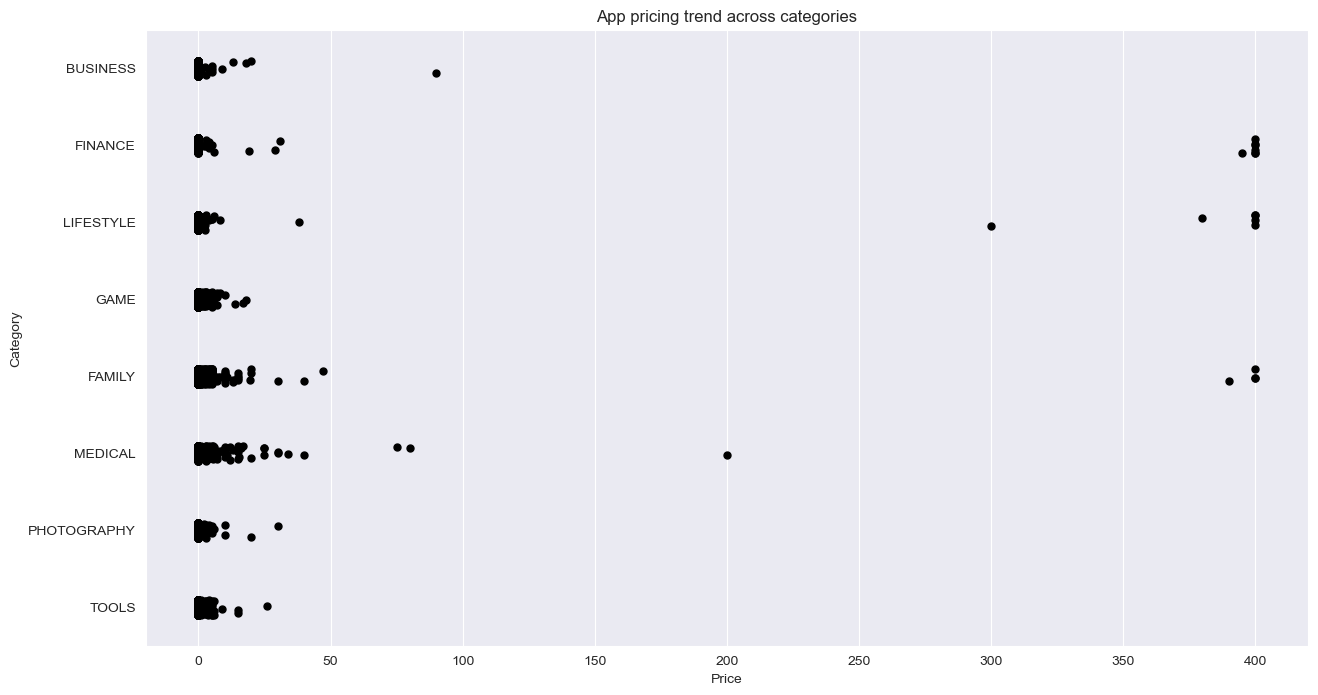

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

# Lista de categorías populares
popular_app_cats = apps[apps.Category.isin(['GAME', 'FAMILY', 'PHOTOGRAPHY',
                                            'MEDICAL', 'TOOLS', 'FINANCE',
                                            'LIFESTYLE','BUSINESS'])]

# Examinamos la tendencia de precio graficando el Precio por Categoría
ax = sns.stripplot(x = popular_app_cats["Price"], y = popular_app_cats["Category"], jitter=True, linewidth=1)
ax.set_title('App pricing trend across categories')

# Seleccionamos las apps con un precio mayor a 200
apps_above_200 = apps[apps["Price"] > 200]
apps_above_200[['Category', 'App', 'Price']]

## VII. Paid apps vs Free apps
<p>Para las aplicaciones de Play Store en la actualidad, existen cinco tipos de estrategias de precios: gratis, "freemium", de pago, "paymium" y de suscripción. Centrémonos solo en aplicaciones gratuitas y de pago. 

Algunas características de las aplicaciones gratuitas son:</p>
<ul>
<li>Libres de descarga.</li>
<li>La principal fuente de ingresos a menudo proviene de la publicidad.</li>
<li>Por lo general son creadaa por empresas que tienen otros productos y la aplicación sirve como una extensión de esos productos.</li>
<li>Puede servir como una herramienta para la retención de clientes, la comunicación y el servicio al cliente.</li>
</ul>
<p>Algunas características de las aplicaciones de paga son:</p>
<ul>
<li>Tienen un tiempo de servicio de prueba gratuito, esto para que el usuario pueda conocerla.</li>
<li>Ofrecen un servicio de mayor especialidad.</li>
</ul>
<p>¿Además de esto que otras características diferencías a las aplicaciones de pago las aplicaciones gratuitas?</p>

##### Otras caracteristicas
Algunas otras características de las aplicaciones gratuitas son:</p>
<ul>
<li>Monetizar a travez de anuncios como una alternativa, dependiendo de la app puede haber un abuso de esto generando desinteres.</li>
<li>Menos retension al no haber un compromiso de pago previo.</li>
<li>Un metodo nuevo conocido como "gacha" a invadido a todos los juegos por su efectividad para monetizar y ah sido una alternativa para desarroladores hacer su juego gratis para aprovechar esto</li>
<li>Al no generar un compromiso por un pago al adquirir el producto suele haber mucha competencia y es mas dificil destacar</li>
<li>Facilidad de adquirir para todoel publico</li> 
</ul>
Algunas otras características de las aplicaciones de paga son:</p>
<li>El pago inicial es una retencion buena para generar compromiso</li>
<li>Te asegura un ingreso por descarga</li>
<li>Se espera que el pago mejore la experiencia de usuario dejando de lado los anuncios</li> 
<li>Muchas apps obtan por tener una version de paga y gratis de la misma app accediendo con el pago a una mejor experiencia</li>
<li>Mayor importancia a nichos</li>
<li>Necesitas mas marketing para llegar a tu publico y que prefieran hacer el pago incial</li>
<li>El pago inicial es un obstaculo para nuevos usuarios</li>

## VIII. Sentiment analysis
<p>La minería de datos de reseñas de usuarios para determinar cómo se sienten las personas acerca de su producto, marca o servicio se puede realizar mediante una técnica llamada análisis de sentimientos. Las reseñas de los usuarios de las aplicaciones se pueden analizar para identificar si el estado de ánimo es positivo, negativo o neutral con respecto a esa aplicación. Por ejemplo, las palabras positivas en la revisión de una aplicación pueden incluir palabras como "asombroso", "amigable", "bueno", "excelente" y "amor". Las palabras negativas pueden ser palabras como 'malware', 'odio', 'problema', 'reembolso' e 'incompetente'.</p>

<p>¿Qué podemos decir acerca del analisis de sentimiento de las aplicaciones?</p>

Text(0.5, 1.0, 'Sentiment Polarity Distribution')

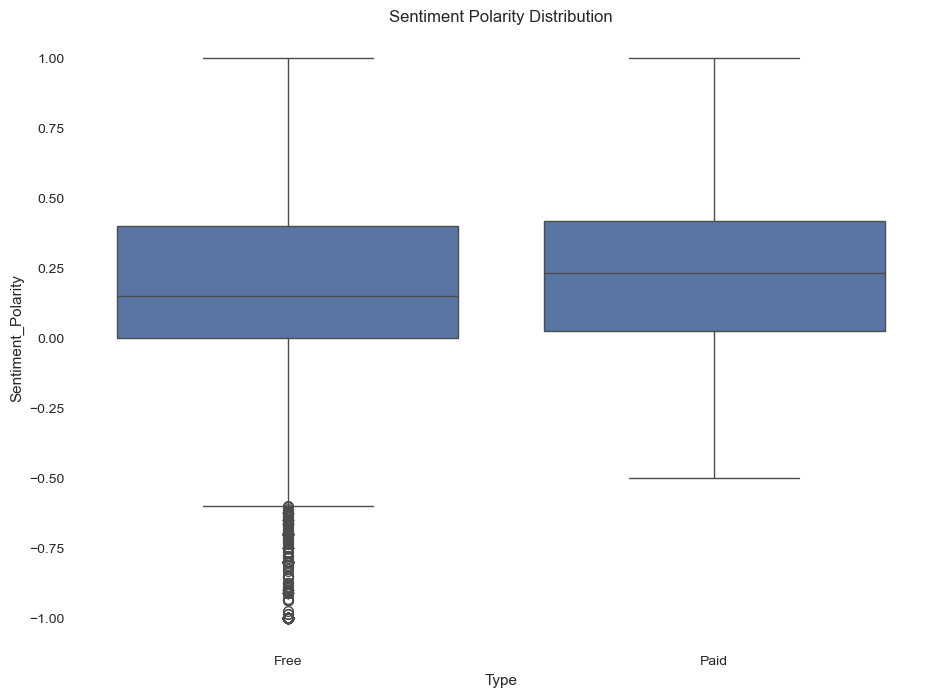

In [17]:
# Cargamos el archivo user_reviews.csv
plt.style.use('seaborn-v0_8') 
reviews_df = pd.read_csv("user_reviews.csv")

# Unimos los dos DataFrames (join)
merged_df = apps.merge(reviews_df, on='App')

# Eliminamos los valores nulos (NA) de las columnas Sentiment y Review
merged_df = merged_df.dropna(subset = ['Sentiment', 'Review'])

# Graficamos la polaridad de sentimientos para apps gratuitas y de paga
sns.set_style('ticks')
fig, ax = plt.subplots()
fig.set_size_inches(11, 8)

ax = sns.boxplot(x = "Type", y = "Sentiment_Polarity", data = merged_df)
ax.set_title('Sentiment Polarity Distribution')

## IX. Conclusion
<P>Se analizaron aproximadamente 10,000 apps de la cuales se vieron que categorias dominaban el mercado y cuales tienen potencial de mercado no aprovechado, sin embargo, se saco el rating promedio por categoria de las apps para no dejarse llevar por la nocion de si una categoria domina el mercado es mas viable o lo contrario si una app no tiene competencia significa que tiene mucho terreno que aborda, esto nos permite tener nocion de que apps por mas dominio de mercado tal vez no sean tan interesantes por su rating a comparacion de otros permitiendo hayar a las que tienen un potencial de mercado mayor con rating promedio mejor a otras categorias.
Despues analizamos la importancia de un peso y precio para una app, para encontrar un peso optimo para generar la mayor cantidad de usuarios, de preferencia con una buena aceptacion y las que tengan un costo como cubren encontrar en que categoria hay mas apps por las que los clientes estan dispuestos a pagar por su importancia de ser una ncesidad para  algunos, pero tambien respondiendo a como las apps que no tienen un costo incial han hallado la forma de monetizar su trabajo donde si la rentabilidad es mayor beneficio para nosotros que un buen rating que si van de la mano mas sin embargo se puede tener un rating moderado monetizando mejor que apps mas aceptadas, adoptando modelos de monetizacion mejor funcionales y por ultimo el sentimiento de satisfaccion cumplir con las espectativas, donde aun las apps de pago que tienen a ser mas tendencisosas a criticas para cumplir el costo inicial son pensadas de mejor manera asegurando en muchos casos una buena aceptacion.
    

## X. Aplicacion de modelo de clasificacion:

<P>

<P>Ahora con nuestras conclusiones, nos interesa saber como alcanzar una app exitosa para monetizar estos datos, aqui entran los modelos de clasificacion donde tengo la intencion de que necesito para crear una app aceptada, para poder monetizarla, de que manera y en que categorias puedo tener mas potencial de aceptacion o popularidad tiniendo menta abierta a mercados menos peleados y similarmente rentables 

In [22]:
#Importamos lo necesario
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import warnings
apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000.0,Free,0.0,Everyone,Art & Design,20180107,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,20180115,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,20180801,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000.0,Free,0.0,Teen,Art & Design,20180608,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,20180620,1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9654,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000.0,Free,0.0,Everyone,Education,20170725,1.48,4.1 and up
9655,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100.0,Free,0.0,Everyone,Education,20180706,1,4.1 and up
9656,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000.0,Free,0.0,Everyone,Medical,20170120,1,2.2 and up
9657,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000.0,Free,0.0,Mature 17+,Books & Reference,20150119,Varies with device,Varies with device


In [23]:
apps_cols=["Category","Rating","Reviews","Size","Type","Price","Content Rating","Genres","Android Ver","Last Updated"]
apps["Rentable"] = (apps["Installs"] >= 50000000).astype(int)
x = apps[apps_cols].values
y = apps["Rentable"].values

In [24]:
#Definimos una funcion con la cual veremos los criterios mas importantes que tomo en cuenta nuestro modelo
import matplotlib.pyplot as plt
import numpy as np
def plot_feature_importance(df,model):
    n_features=apps_cols
    plt.barh(n_features,model.feature_importances_,align="center")
    plt.xlabel("Importancia de las variables")
    plt.ylabel("Caracteristicas")
    plt.show()

In [25]:
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
apps_category = preprocessing.LabelEncoder()
apps_category.fit(["FAMILY","GAME","TOOLS","BUSINESS","MEDICAL","PERSONALIZATION","PRODUCTIVITY","LIFESTYLE","FINANCE","SPORTS","COMMUNICATION","HEALTH_AND_FITNESS",      
"PHOTOGRAPHY","NEWS_AND_MAGAZINES","SOCIAL","BOOKS_AND_REFERENCE","TRAVEL_AND_LOCAL","SHOPPING","DATING","VIDEO_PLAYERS","MAPS_AND_NAVIGATION","EDUCATION",              
"FOOD_AND_DRINK","ENTERTAINMENT","AUTO_AND_VEHICLES","LIBRARIES_AND_DEMO","WEATHER","HOUSE_AND_HOME","ART_AND_DESIGN","EVENTS","PARENTING","COMICS","BEAUTY"])  # Lista completa de categorías de aplicaciones
x[:, 0] = apps_category.transform(x[:, 0])

apps_type = preprocessing.LabelEncoder()
apps_type.fit(["Free", "Paid"])
x[:, 4] = apps_type.transform(x[:, 4])

apps_content = preprocessing.LabelEncoder()
apps_content.fit(["Everyone", "Teen", "Mature 17+", "Everyone 10+", "Adults only 18+", "Unrated"])
x[:, 6] = apps_content.transform(x[:, 6])  

apps_genres = preprocessing.LabelEncoder()
apps_genres.fit(["Tools", "Entertainment", "Education", "Business", "Medical", "Personalization", 
    "Productivity", "Lifestyle", "Finance", "Sports", "Communication", "Action", 
    "Health & Fitness", "Photography", "News & Magazines", "Social", "Books & Reference", 
    "Travel & Local", "Shopping", "Simulation", "Arcade", "Dating", "Casual", 
    "Video Players & Editors", "Maps & Navigation", "Puzzle", "Food & Drink", 
    "Role Playing", "Strategy", "Racing", "Auto & Vehicles", "Libraries & Demo", 
    "Weather", "House & Home", "Adventure", "Events", "Art & Design", "Comics", 
    "Beauty", "Card", "Parenting", "Board", "Casino", "Educational;Education", 
    "Trivia", "Educational", "Education;Education", "Casual;Pretend Play", "Word", 
    "Music", "Education;Pretend Play", "Puzzle;Brain Games", "Racing;Action & Adventure", 
    "Entertainment;Music & Video", "Board;Brain Games", "Arcade;Action & Adventure", 
    "Educational;Pretend Play", "Casual;Action & Adventure", "Casual;Brain Games", 
    "Action;Action & Adventure", "Entertainment;Brain Games", "Parenting;Education", 
    "Simulation;Action & Adventure", "Casual;Creativity", "Art & Design;Creativity", 
    "Education;Creativity", "Educational;Brain Games", "Parenting;Music & Video", 
    "Educational;Creativity", "Adventure;Action & Adventure", "Education;Brain Games", 
    "Role Playing;Pretend Play", "Role Playing;Action & Adventure", "Sports;Action & Adventure", 
    "Education;Action & Adventure", "Education;Music & Video", "Entertainment;Creativity", 
    "Simulation;Education", "Simulation;Pretend Play", "Puzzle;Action & Adventure", 
    "Entertainment;Action & Adventure", "Music;Music & Video", "Board;Action & Adventure", 
    "Educational;Action & Adventure", "Casual;Education", "Card;Action & Adventure", 
    "Strategy;Action & Adventure", "Puzzle;Creativity", "Entertainment;Pretend Play", 
    "Video Players & Editors;Music & Video", "Books & Reference;Education", 
    "Art & Design;Pretend Play", "Art & Design;Action & Adventure", "Comics;Creativity", 
    "Lifestyle;Pretend Play", "Board;Pretend Play", "Casual;Music & Video", 
    "Health & Fitness;Education", "Adventure;Education", "Music & Audio;Music & Video", 
    "Entertainment;Education", "Arcade;Pretend Play", "Video Players & Editors;Creativity", 
    "Parenting;Brain Games", "Travel & Local;Action & Adventure", "Tools;Education", 
    "Adventure;Brain Games", "Trivia;Education", "Lifestyle;Education", 
    "Health & Fitness;Action & Adventure", "Books & Reference;Creativity", 
    "Puzzle;Education", "Role Playing;Education", "Role Playing;Brain Games", 
    "Strategy;Education", "Racing;Pretend Play", "Communication;Creativity", 
    "Strategy;Creativity"])  # Lista completa de géneros
x[:, 7] = apps_genres.transform(x[:, 7])

android_groups = {"Alto potencial de instalación (Android 8+)": [
        "8.0 and up", "8.1 and up", "9.0 and up",
        "10.0 and up", "11.0 and up", "12.0 and up",
        "13.0 and up", "10.0 - 11.0", "12.1 and up",
        "7.1 - 9.0"  
    ],
    "Compatibilidad media (Android 5-7)": [
        "5.0 and up", "5.1 and up", "6.0 and up",
        "7.0 and up", "5.0 - 7.1.1", "7.0 - 8.0",
        "4.4 and up" 
    ],
    "Baja compatibilidad (Android 2-4)": [
        "2.3 and up", "3.0 and up", "4.0 and up",
        "4.1 and up", "Varies with device", "NO_DATA"]}
android_mapping = {value: key for key, values in android_groups.items() for value in values}
x[:, 8] = np.vectorize(android_mapping.get)(x[:,8])
android_ver_grouped = preprocessing.LabelEncoder()
x[:, 8] = android_ver_grouped.fit_transform(x[:,8])


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=1)
rf=RandomForestClassifier(class_weight= {0: 1, 1: 5}, max_depth= None, max_features= 'sqrt', min_samples_leaf= 4, min_samples_split= 2, n_estimators= 100)
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
y_proba = rf.predict_proba(x_test)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))  
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       925
           1       0.67      0.83      0.74        41

    accuracy                           0.98       966
   macro avg       0.83      0.91      0.86       966
weighted avg       0.98      0.98      0.98       966

ROC AUC: 0.9865524060646012

Matriz de Confusión:
[[908  17]
 [  7  34]]


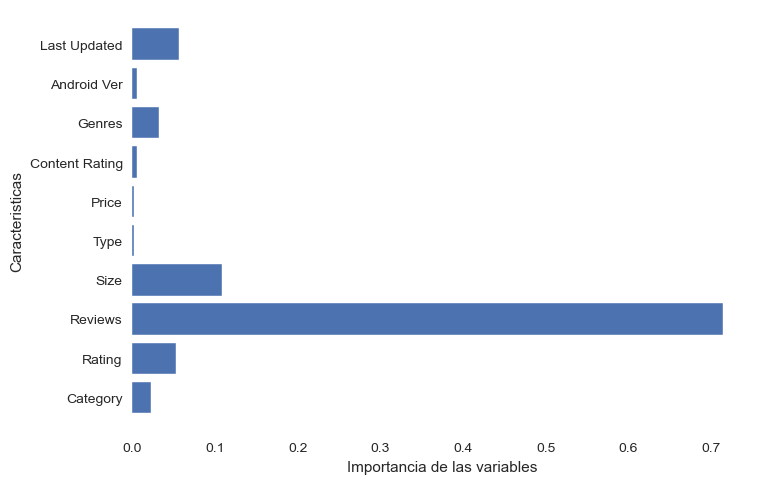

In [27]:
plot_feature_importance(apps,rf)

<P>Al usar nuestro modelo vemos la importancia de la columna "Reviews" que es algo facil de inducir pues si algo tuvo muchas reviews por ende su popularidad fue mucha, el marketing tiene un trabajo importante en generar interaccion,ya que se suele tener menor reviws a comparacion del numero de descargas, esto nos habla que ah mayor interaccion mayor popularidad sin embargo no nos sirve para predecir desde "0" si una app tiene todo para ser popular pues el logico que si alcanze mucha gente yo tenga mayor numero de reviws, asi que queremos que si su tendencia por factores propios de la app destaquen tenemos que hacer nuestro modelo sin contemplar esta interaccion para responde la pregunta: ¿Mi app en desarrollo o en la que invertire que parametros debe cumplir, a cuales me debo adaptar y que debo considerar para segurar su exito?

## XI Parametros clave

In [30]:
apps_cols=["Category","Rating","Size","Type","Price","Content Rating","Genres","Android Ver","Last Updated"]
apps["Rentable"] = (apps["Installs"] >= 50000000).astype(int)
x = apps[apps_cols].values
y = apps["Rentable"].values

In [31]:
apps_category = preprocessing.LabelEncoder()
apps_category.fit(["FAMILY","GAME","TOOLS","BUSINESS","MEDICAL","PERSONALIZATION","PRODUCTIVITY","LIFESTYLE","FINANCE","SPORTS","COMMUNICATION","HEALTH_AND_FITNESS",      
"PHOTOGRAPHY","NEWS_AND_MAGAZINES","SOCIAL","BOOKS_AND_REFERENCE","TRAVEL_AND_LOCAL","SHOPPING","DATING","VIDEO_PLAYERS","MAPS_AND_NAVIGATION","EDUCATION",              
"FOOD_AND_DRINK","ENTERTAINMENT","AUTO_AND_VEHICLES","LIBRARIES_AND_DEMO","WEATHER","HOUSE_AND_HOME","ART_AND_DESIGN","EVENTS","PARENTING","COMICS","BEAUTY"])  # Lista completa de categorías de aplicaciones
x[:, 0] = apps_category.transform(x[:, 0])

apps_type = preprocessing.LabelEncoder()
apps_type.fit(["Free", "Paid"])
x[:, 3] = apps_type.transform(x[:, 3])

apps_content = preprocessing.LabelEncoder()
apps_content.fit(["Everyone", "Teen", "Mature 17+", "Everyone 10+", "Adults only 18+", "Unrated"])
x[:, 5] = apps_content.transform(x[:, 5])  

apps_genres = preprocessing.LabelEncoder()
apps_genres.fit(["Tools", "Entertainment", "Education", "Business", "Medical", "Personalization", 
    "Productivity", "Lifestyle", "Finance", "Sports", "Communication", "Action", 
    "Health & Fitness", "Photography", "News & Magazines", "Social", "Books & Reference", 
    "Travel & Local", "Shopping", "Simulation", "Arcade", "Dating", "Casual", 
    "Video Players & Editors", "Maps & Navigation", "Puzzle", "Food & Drink", 
    "Role Playing", "Strategy", "Racing", "Auto & Vehicles", "Libraries & Demo", 
    "Weather", "House & Home", "Adventure", "Events", "Art & Design", "Comics", 
    "Beauty", "Card", "Parenting", "Board", "Casino", "Educational;Education", 
    "Trivia", "Educational", "Education;Education", "Casual;Pretend Play", "Word", 
    "Music", "Education;Pretend Play", "Puzzle;Brain Games", "Racing;Action & Adventure", 
    "Entertainment;Music & Video", "Board;Brain Games", "Arcade;Action & Adventure", 
    "Educational;Pretend Play", "Casual;Action & Adventure", "Casual;Brain Games", 
    "Action;Action & Adventure", "Entertainment;Brain Games", "Parenting;Education", 
    "Simulation;Action & Adventure", "Casual;Creativity", "Art & Design;Creativity", 
    "Education;Creativity", "Educational;Brain Games", "Parenting;Music & Video", 
    "Educational;Creativity", "Adventure;Action & Adventure", "Education;Brain Games", 
    "Role Playing;Pretend Play", "Role Playing;Action & Adventure", "Sports;Action & Adventure", 
    "Education;Action & Adventure", "Education;Music & Video", "Entertainment;Creativity", 
    "Simulation;Education", "Simulation;Pretend Play", "Puzzle;Action & Adventure", 
    "Entertainment;Action & Adventure", "Music;Music & Video", "Board;Action & Adventure", 
    "Educational;Action & Adventure", "Casual;Education", "Card;Action & Adventure", 
    "Strategy;Action & Adventure", "Puzzle;Creativity", "Entertainment;Pretend Play", 
    "Video Players & Editors;Music & Video", "Books & Reference;Education", 
    "Art & Design;Pretend Play", "Art & Design;Action & Adventure", "Comics;Creativity", 
    "Lifestyle;Pretend Play", "Board;Pretend Play", "Casual;Music & Video", 
    "Health & Fitness;Education", "Adventure;Education", "Music & Audio;Music & Video", 
    "Entertainment;Education", "Arcade;Pretend Play", "Video Players & Editors;Creativity", 
    "Parenting;Brain Games", "Travel & Local;Action & Adventure", "Tools;Education", 
    "Adventure;Brain Games", "Trivia;Education", "Lifestyle;Education", 
    "Health & Fitness;Action & Adventure", "Books & Reference;Creativity", 
    "Puzzle;Education", "Role Playing;Education", "Role Playing;Brain Games", 
    "Strategy;Education", "Racing;Pretend Play", "Communication;Creativity", 
    "Strategy;Creativity"])  # Lista completa de géneros
x[:, 6] = apps_genres.transform(x[:, 6])

android_groups = {"Alto potencial de instalación (Android 8+)": [
        "8.0 and up", "8.1 and up", "9.0 and up",
        "10.0 and up", "11.0 and up", "12.0 and up",
        "13.0 and up", "10.0 - 11.0", "12.1 and up",
        "7.1 - 9.0"  
    ],
    "Compatibilidad media (Android 5-7)": [
        "5.0 and up", "5.1 and up", "6.0 and up",
        "7.0 and up", "5.0 - 7.1.1", "7.0 - 8.0",
        "4.4 and up" 
    ],
    "Baja compatibilidad (Android 2-4)": [
        "2.3 and up", "3.0 and up", "4.0 and up",
        "4.1 and up", "Varies with device", "NO_DATA"]}
android_mapping = {value: key for key, values in android_groups.items() for value in values}
x[:, 7] = np.vectorize(android_mapping.get)(x[:,7])
android_ver_grouped = preprocessing.LabelEncoder()
x[:, 7] = android_ver_grouped.fit_transform(x[:,7])


In [32]:
from sklearn.ensemble import RandomForestClassifier
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=1)
rf=RandomForestClassifier(class_weight= 'balanced', max_depth= None, max_features= 'sqrt', min_samples_leaf= 4, min_samples_split= 2, n_estimators= 200)
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
y_proba = rf.predict_proba(x_test)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))  
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       925
           1       0.33      0.54      0.41        41

    accuracy                           0.93       966
   macro avg       0.65      0.74      0.69       966
weighted avg       0.95      0.93      0.94       966

ROC AUC: 0.9363085036255767

Matriz de Confusión:
[[880  45]
 [ 19  22]]


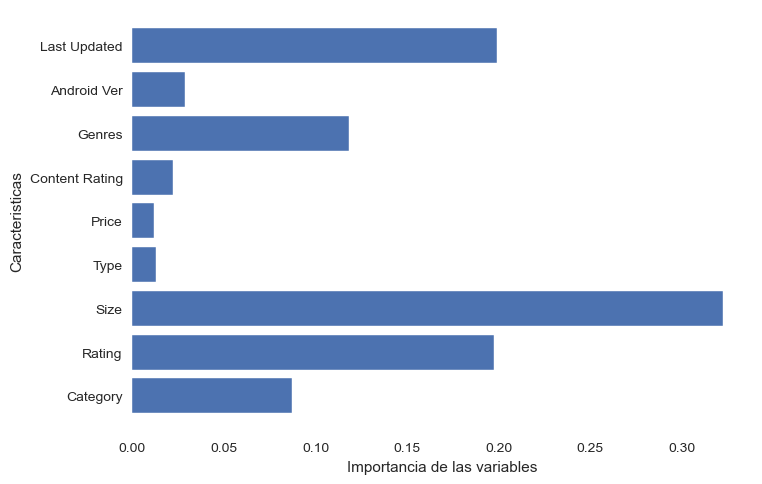

In [33]:
plot_feature_importance(apps, rf)

<p>Ahora si podremos ver que varibales son relevantes en el exito de una app previoa un marketing que cosas tienden a funcionar:</p>
<p>Last Updated: Nuestra app debe estar en constante actualizacion para satisfacer las necesidades del mercado que evoluciona constantemente</p>
<p>Size: El espacio debe ser adecuado para ocupar un lugar con nuestro usuario y mientras mas elevado sea se debe justificar por la necesidad de usuario por esa app</p>
<p>Rating: Nos dice que la aceptacion es adecuado y que complimos con las necesidades de quien nos descarga</p>
<p>Genres: Que usos especificos para aplicaciones destacan mas</p>
<p>Category: Que usos generales para aplicaciones destacan mas</p>
<p>Android Ver: La compatibilidad con los dispositivos de los usuarios</p>

## XII Calidad sobre cantidad

<p>Ya podemos predecir apps pupulares y sabemos sus parametros clave ahora, es mejor que nuestra app represente una inversion segura pues aunque sea popular la gente estara de acuerdo con aceptar la manera en que la monetizaremos?, esto dependera si la gente piensa si nuestra app vale la pena cumplio con todo para ganarse su lugar teniendo los parametros correctos para ello; Esto lo podemos saber gracias al rating que nos relaciona segun cada genero y categoria de la app, si cumplio con el peso adecuado segun su importancia, le dimos el precio adecuado o seleccionamos el publico correcto apra ella, asi que predeciremos el Rating la medida con que los usuarios nos dicen si estan satisfechos o no con nuestra app 

In [37]:
apps_cols=["Category","Size","Type","Price","Content Rating","Genres","Android Ver","Last Updated"]
apps["RatingBueno"] = (apps["Rating"] >= 4).astype(int)
apps_clean = apps.dropna(subset=['Rating'])
x = apps_clean[apps_cols].values
y = apps_clean["RatingBueno"].values

In [38]:
apps_category = preprocessing.LabelEncoder()
apps_category.fit(["FAMILY","GAME","TOOLS","BUSINESS","MEDICAL","PERSONALIZATION","PRODUCTIVITY","LIFESTYLE","FINANCE","SPORTS","COMMUNICATION","HEALTH_AND_FITNESS",      
"PHOTOGRAPHY","NEWS_AND_MAGAZINES","SOCIAL","BOOKS_AND_REFERENCE","TRAVEL_AND_LOCAL","SHOPPING","DATING","VIDEO_PLAYERS","MAPS_AND_NAVIGATION","EDUCATION",              
"FOOD_AND_DRINK","ENTERTAINMENT","AUTO_AND_VEHICLES","LIBRARIES_AND_DEMO","WEATHER","HOUSE_AND_HOME","ART_AND_DESIGN","EVENTS","PARENTING","COMICS","BEAUTY"])  # Lista completa de categorías de aplicaciones
x[:, 0] = apps_category.transform(x[:, 0])

apps_type = preprocessing.LabelEncoder()
apps_type.fit(["Free", "Paid"])
x[:, 2] = apps_type.transform(x[:, 2])

apps_content = preprocessing.LabelEncoder()
apps_content.fit(["Everyone", "Teen", "Mature 17+", "Everyone 10+", "Adults only 18+", "Unrated"])
x[:, 4] = apps_content.transform(x[:, 4])  

apps_genres = preprocessing.LabelEncoder()
apps_genres.fit(["Tools", "Entertainment", "Education", "Business", "Medical", "Personalization", 
    "Productivity", "Lifestyle", "Finance", "Sports", "Communication", "Action", 
    "Health & Fitness", "Photography", "News & Magazines", "Social", "Books & Reference", 
    "Travel & Local", "Shopping", "Simulation", "Arcade", "Dating", "Casual", 
    "Video Players & Editors", "Maps & Navigation", "Puzzle", "Food & Drink", 
    "Role Playing", "Strategy", "Racing", "Auto & Vehicles", "Libraries & Demo", 
    "Weather", "House & Home", "Adventure", "Events", "Art & Design", "Comics", 
    "Beauty", "Card", "Parenting", "Board", "Casino", "Educational;Education", 
    "Trivia", "Educational", "Education;Education", "Casual;Pretend Play", "Word", 
    "Music", "Education;Pretend Play", "Puzzle;Brain Games", "Racing;Action & Adventure", 
    "Entertainment;Music & Video", "Board;Brain Games", "Arcade;Action & Adventure", 
    "Educational;Pretend Play", "Casual;Action & Adventure", "Casual;Brain Games", 
    "Action;Action & Adventure", "Entertainment;Brain Games", "Parenting;Education", 
    "Simulation;Action & Adventure", "Casual;Creativity", "Art & Design;Creativity", 
    "Education;Creativity", "Educational;Brain Games", "Parenting;Music & Video", 
    "Educational;Creativity", "Adventure;Action & Adventure", "Education;Brain Games", 
    "Role Playing;Pretend Play", "Role Playing;Action & Adventure", "Sports;Action & Adventure", 
    "Education;Action & Adventure", "Education;Music & Video", "Entertainment;Creativity", 
    "Simulation;Education", "Simulation;Pretend Play", "Puzzle;Action & Adventure", 
    "Entertainment;Action & Adventure", "Music;Music & Video", "Board;Action & Adventure", 
    "Educational;Action & Adventure", "Casual;Education", "Card;Action & Adventure", 
    "Strategy;Action & Adventure", "Puzzle;Creativity", "Entertainment;Pretend Play", 
    "Video Players & Editors;Music & Video", "Books & Reference;Education", 
    "Art & Design;Pretend Play", "Art & Design;Action & Adventure", "Comics;Creativity", 
    "Lifestyle;Pretend Play", "Board;Pretend Play", "Casual;Music & Video", 
    "Health & Fitness;Education", "Adventure;Education", "Music & Audio;Music & Video", 
    "Entertainment;Education", "Arcade;Pretend Play", "Video Players & Editors;Creativity", 
    "Parenting;Brain Games", "Travel & Local;Action & Adventure", "Tools;Education", 
    "Adventure;Brain Games", "Trivia;Education", "Lifestyle;Education", 
    "Health & Fitness;Action & Adventure", "Books & Reference;Creativity", 
    "Puzzle;Education", "Role Playing;Education", "Role Playing;Brain Games", 
    "Strategy;Education", "Racing;Pretend Play", "Communication;Creativity", 
    "Strategy;Creativity"])  # Lista completa de géneros
x[:, 5] = apps_genres.transform(x[:, 5])

android_groups = {"Alto potencial de instalación (Android 8+)": [
        "8.0 and up", "8.1 and up", "9.0 and up",
        "10.0 and up", "11.0 and up", "12.0 and up",
        "13.0 and up", "10.0 - 11.0", "12.1 and up",
        "7.1 - 9.0"  
    ],
    "Compatibilidad media (Android 5-7)": [
        "5.0 and up", "5.1 and up", "6.0 and up",
        "7.0 and up", "5.0 - 7.1.1", "7.0 - 8.0",
        "4.4 and up" 
    ],
    "Baja compatibilidad (Android 2-4)": [
        "2.3 and up", "3.0 and up", "4.0 and up",
        "4.1 and up", "Varies with device", "NO_DATA"]}
android_mapping = {value: key for key, values in android_groups.items() for value in values}
x[:, 6] = np.vectorize(android_mapping.get)(x[:,6])
android_ver_grouped = preprocessing.LabelEncoder()
x[:, 6] = android_ver_grouped.fit_transform(x[:,6])


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=1)

model = RandomForestClassifier(
    n_estimators=150,          
    max_depth=20,              
    class_weight={0: 3, 1: 1}, 
    max_samples=0.8,           
    random_state=1,
    n_jobs=-1             )
model.fit(x_train, y_train)
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.24      0.33       180
           1       0.82      0.94      0.87       640

    accuracy                           0.79       820
   macro avg       0.67      0.59      0.60       820
weighted avg       0.75      0.79      0.75       820

Matriz de Confusión:
 [[ 44 136]
 [ 40 600]]


<p>Este modelo cumple su objetivo de detectar las que si tendran una buena aceptacion que es lo que buscamos, donde podremos predecir con seguridad para nuestras apps y Saber si nuestros parametros fueron los correctos para asegurar su aceptacion

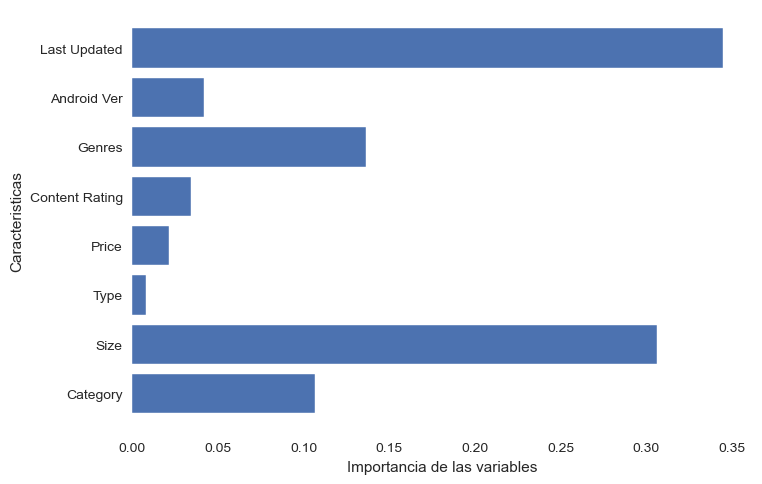

In [41]:
plot_feature_importance(apps, model)

<p>Podemos concluir que nuestro modelo de prediccion no puede dar con certeza una guia para quien busque invertir o crear una app con seguridad para que esta llegue a ser rentable, donbde tambien puede ver si ah elejido las caracteristicas el espacio o precio correcto para el exito de su app llamando la atencion de su publico objetivo, no solo como tendencia si no satisfaciendo esa comunidad generando una fidelidad a esta app</p>
<P>Atte. <a href="www.linkedin.com/in/hiram-cruz-data-science">Hiram Cruz</a></p>